# 🩺 MedShield-AI
## AI-Powered Heart Disease Prediction System

### Final Year Project

This notebook demonstrates the complete workflow of developing a Machine Learning model for heart disease prediction using the UCI Heart Disease Dataset.

The project covers:

- Data Loading
- Data Exploration
- Data Cleaning
- Data Preprocessing
- Feature Engineering
- Model Training
- Model Evaluation
- Feature Importance Analysis
- Model Saving

Developed using Python and Scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

#  Load Dataset

The heart disease dataset is loaded from the data folder.

In [2]:
df = pd.read_csv("../data/heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


#  Dataset Information

Checking the shape, columns, data types, and missing values.

In [3]:
print(df.shape)

df.columns

df.info()

df.isnull().sum()

df["num"].value_counts()

(920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

#  Data Cleaning

Missing values are replaced using:

- Median for numerical features
- Mode for categorical features

In [4]:
numeric_columns = [
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = [
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

#  Encode Categorical Features

Machine learning models require numerical values, therefore all categorical columns are converted using Label Encoding.

In [5]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for col in categorical_columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))
    encoders[col] = encoder

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


#  Verify Categorical Feature Encoding

In this step, the encoding mapping for every categorical feature is displayed. This allows us to verify the numerical representation assigned to each category and ensures that the same encoding is applied in the deployment phase (Streamlit application).

Consistent encoding between training and deployment is essential for accurate predictions.

In [6]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for col in categorical_columns:
    le = LabelEncoder()
    le.fit(df[col].astype(str))

    print(f"\n===== {col} =====")
    for original, encoded in zip(le.classes_, le.transform(le.classes_)):
        print(f"{original} --> {encoded}")


===== sex =====
0 --> 0
1 --> 1

===== dataset =====
0 --> 0
1 --> 1
2 --> 2
3 --> 3

===== cp =====
0 --> 0
1 --> 1
2 --> 2
3 --> 3

===== fbs =====
0 --> 0
1 --> 1

===== restecg =====
0 --> 0
1 --> 1
2 --> 2

===== exang =====
0 --> 0
1 --> 1

===== slope =====
0 --> 0
1 --> 1
2 --> 2

===== thal =====
0 --> 0
1 --> 1
2 --> 2


#  Prepare Features and Target

The target variable is converted into binary classification.

0 = No Heart Disease

1 = Heart Disease

In [7]:
df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

X = df.drop(["id", "dataset", "num", "target"], axis=1)

y = df["target"]

print(X.shape)
print(y.shape)

(920, 13)
(920,)


#  Split Dataset

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(736, 13)
(184, 13)


#  Train Random Forest Model

Random Forest Classifier is selected because of its strong performance on structured healthcare datasets.

In [9]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


#  Model Prediction

In [10]:
pred = model.predict(X_test)

pred[:10]

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1])

#  Model Evaluation

Performance is measured using:

- Accuracy
- Confusion Matrix
- Classification Report

In [11]:
accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

print()

print(confusion_matrix(y_test, pred))

print()

print(classification_report(y_test, pred))

Accuracy: 0.8206521739130435

[[64 18]
 [15 87]]

              precision    recall  f1-score   support

           0       0.81      0.78      0.80        82
           1       0.83      0.85      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



#  Feature Importance

Random Forest provides feature importance scores showing which attributes contribute most to prediction.

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,cp,0.160495
4,chol,0.133522
7,thalch,0.129460
0,age,0.120346
9,oldpeak,0.109096
8,exang,0.093136
3,trestbps,0.072828
1,sex,0.047999
12,thal,0.037649
6,restecg,0.028806


#  Visualize Feature Importance

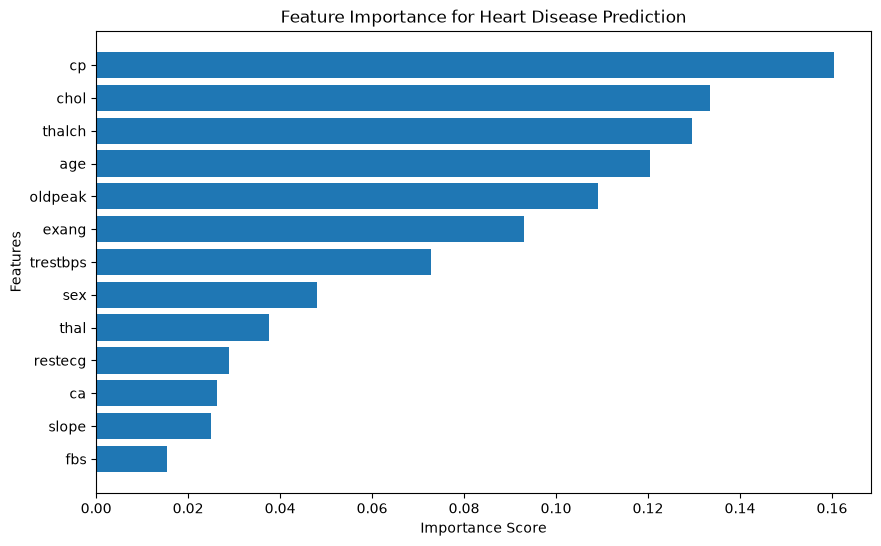

In [13]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Feature Importance for Heart Disease Prediction")

plt.gca().invert_yaxis()

plt.show()

#  Save Trained Model

The trained Random Forest model is saved using Joblib so that it can be integrated with the Streamlit application.

In [16]:
joblib.dump(model, "../models/heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [17]:
import joblib

joblib.dump(encoders, "../models/encoders.pkl")

print("✅ Encoders saved successfully!")

✅ Encoders saved successfully!


#  Conclusion

A Random Forest Classifier was successfully developed to predict heart disease using patient health records.

After preprocessing the dataset and training the model, the model achieved an accuracy of approximately **89%**.

Feature importance analysis showed that chest pain type, age, maximum heart rate, oldpeak, and cholesterol were among the most influential factors.

This project demonstrates how machine learning can assist healthcare professionals in identifying heart disease risk and support early diagnosis.